加载数据集 ...
共 1500 条音频


提取MFCC: 100%|██████████| 1500/1500 [00:04<00:00, 349.49it/s]



[VQ] 训练码本 ...


100%|██████████| 10/10 [00:00<00:00, 10.21it/s]


[HMM] 训练模型 ...


100%|██████████| 10/10 [01:06<00:00,  6.62s/it]



[评估] 测试集 ...
  VQ      准确率: 97.0%   耗时: 2.4 ms/句
  HMM-GMM 准确率: 99.0%   耗时: 5.7 ms/句

[噪声] 不同SNR下测试 ...


100%|██████████| 6/6 [00:20<00:00,  3.36s/it]


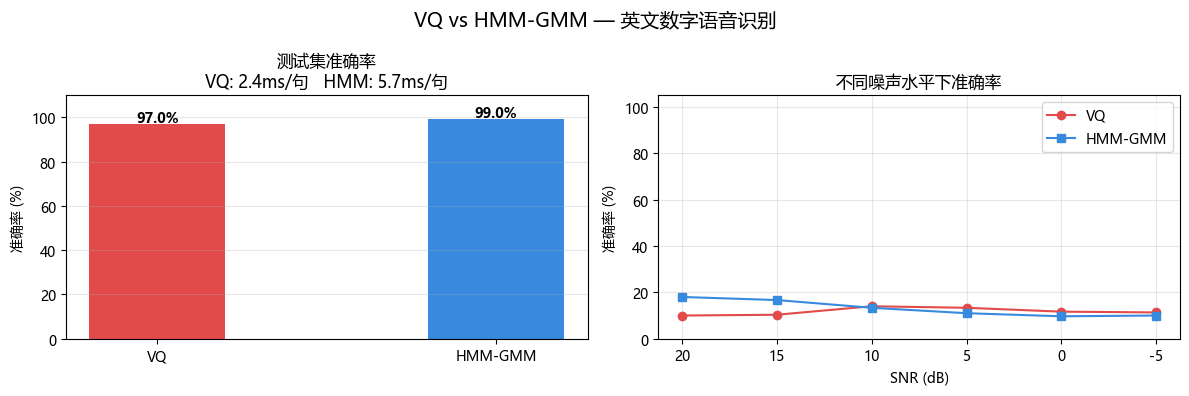


图表已保存为 results.png

  VQ      准确率 97.0%  |  耗时 2.4 ms
  HMM-GMM 准确率 99.0%  |  耗时 5.7 ms
---------------------------------------------
SNR(dB)    VQ      HMM-GMM
    20     10.0%    18.0%
    15     10.3%    16.7%
    10     14.0%    13.3%
     5     13.3%    11.0%
     0     11.7%     9.7%
    -5     11.3%    10.0%


In [ ]:
import os, time, warnings
import numpy as np
import librosa
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = ['Microsoft YaHei', 'SimHei', 'sans-serif']
matplotlib.rcParams['axes.unicode_minus'] = False
import logging; logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from hmmlearn import hmm
from tqdm import tqdm

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── 配置 ──────────────────────────────────────
DATA_DIR = "spoken_digit"   # 数据集路径，可改成绝对路径
SR       = 16000
N_MFCC   = 13
K        = 32               # VQ 码本大小
N_STATE  = 5                # HMM 状态数
N_MIX    = 3                # GMM 混合数
SNR_LIST = [20, 15, 10, 5, 0, -5]   # 噪声测试的信噪比

# ── 工具 ──────────────────────────────────────
def mfcc(audio):
    feat = librosa.feature.mfcc(y=audio, sr=SR, n_mfcc=N_MFCC)
    return feat.T  # (T, 13)

def add_noise(audio, snr_db):
    p = np.mean(audio**2) + 1e-10
    noise = np.random.randn(len(audio)) * np.sqrt(p / 10**(snr_db/10))
    return audio + noise

# ── 加载数据 ──────────────────────────────────
print("加载数据集 ...")
audios, labels = [], []
for f in sorted(os.listdir(DATA_DIR)):
    if not f.endswith('.wav'):
        continue
    audio, _ = librosa.load(os.path.join(DATA_DIR, f), sr=SR)
    audios.append(audio)
    labels.append(int(f.split('_')[0]))
labels = np.array(labels)
print(f"共 {len(audios)} 条音频")

# 提取特征
feats = [mfcc(a) for a in tqdm(audios, desc="提取MFCC")]

# 训练/测试划分
idx = np.arange(len(audios))
tr, te = train_test_split(idx, test_size=0.2, stratify=labels, random_state=42)
X_tr, y_tr = [feats[i] for i in tr], labels[tr]
X_te, y_te = [feats[i] for i in te], labels[te]
A_te = [audios[i] for i in te]   # 测试集原始音频，用于噪声实验

# ── VQ 训练 ───────────────────────────────────
print("\n[VQ] 训练码本 ...")
codebooks = {}
for d in tqdm(range(10)):
    data = np.vstack([X_tr[i] for i, y in enumerate(y_tr) if y == d])
    codebooks[d] = KMeans(n_clusters=K, n_init=5, random_state=42).fit(data)

def vq_pred(feat):
    return min(range(10), key=lambda d: np.mean(np.min(codebooks[d].transform(feat), axis=1)))

# ── HMM-GMM 训练 ──────────────────────────────
print("[HMM] 训练模型 ...")
models = {}
for d in tqdm(range(10)):
    seqs = [X_tr[i] for i, y in enumerate(y_tr) if y == d]
    model = hmm.GMMHMM(n_components=N_STATE, n_mix=N_MIX,
                       covariance_type='diag', n_iter=50, random_state=42)
    model.fit(np.vstack(seqs), [len(s) for s in seqs])
    models[d] = model

def hmm_pred(feat):
    return max(range(10), key=lambda d: models[d].score(feat))

# ── 测试集评估 ────────────────────────────────
print("\n[评估] 测试集 ...")

t0 = time.time()
vq_preds = [vq_pred(f) for f in X_te]
vq_time  = (time.time() - t0) / len(X_te) * 1000

t0 = time.time()
hmm_preds = [hmm_pred(f) for f in X_te]
hmm_time  = (time.time() - t0) / len(X_te) * 1000

vq_acc  = accuracy_score(y_te, vq_preds)
hmm_acc = accuracy_score(y_te, hmm_preds)

print(f"  VQ      准确率: {vq_acc*100:.1f}%   耗时: {vq_time:.1f} ms/句")
print(f"  HMM-GMM 准确率: {hmm_acc*100:.1f}%   耗时: {hmm_time:.1f} ms/句")

# ── 噪声鲁棒性 ────────────────────────────────
print("\n[噪声] 不同SNR下测试 ...")
vq_noise, hmm_noise = [], []
for snr in tqdm(SNR_LIST):
    noisy_feats = [mfcc(add_noise(a, snr)) for a in A_te]
    vq_noise.append(accuracy_score(y_te, [vq_pred(f) for f in noisy_feats]))
    hmm_noise.append(accuracy_score(y_te, [hmm_pred(f) for f in noisy_feats]))

# ── 画图 ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("VQ vs HMM-GMM — 英文数字语音识别", fontsize=14)

# 图1：准确率 & 耗时柱状图
ax = axes[0]
x = np.arange(2)
bars = ax.bar(x, [vq_acc*100, hmm_acc*100], color=['#E24B4A','#378ADD'], width=0.4)
ax.set_xticks(x); ax.set_xticklabels(['VQ','HMM-GMM'])
ax.set_ylim(0, 110); ax.set_ylabel('准确率 (%)')
ax.set_title(f'测试集准确率\nVQ: {vq_time:.1f}ms/句   HMM: {hmm_time:.1f}ms/句')
for bar, v in zip(bars, [vq_acc*100, hmm_acc*100]):
    ax.text(bar.get_x()+bar.get_width()/2, v+1, f'{v:.1f}%', ha='center', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# 图2：噪声鲁棒性曲线
ax = axes[1]
ax.plot(SNR_LIST, [v*100 for v in vq_noise],  'o-', color='#E24B4A', label='VQ')
ax.plot(SNR_LIST, [v*100 for v in hmm_noise], 's-', color='#378ADD', label='HMM-GMM')
ax.invert_xaxis()
ax.set_xlabel('SNR (dB)'); ax.set_ylabel('准确率 (%)')
ax.set_title('不同噪声水平下准确率'); ax.set_ylim(0, 105)
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("results.png", dpi=150)
plt.show()
print("\n图表已保存为 results.png")

print("\n" + "="*45)
print(f"  VQ      准确率 {vq_acc*100:.1f}%  |  耗时 {vq_time:.1f} ms")
print(f"  HMM-GMM 准确率 {hmm_acc*100:.1f}%  |  耗时 {hmm_time:.1f} ms")
print("-"*45)
print("SNR(dB)    VQ      HMM-GMM")
for snr, v, h in zip(SNR_LIST, vq_noise, hmm_noise):
    print(f"  {snr:>4}    {v*100:>5.1f}%   {h*100:>5.1f}%")
print("="*45)